#Technical Terms

**Partition-based Clustering:** Divides data into a fixed number of groups based on similarity.

**K-means:** Groups data by assigning each point to the nearest cluster center.

**K-medoids / PAM:** Similar to K-means but uses actual data points as cluster centers for better stability.

**Hierarchical Clustering:** Builds a tree-like structure of clusters by progressively merging or splitting them.

**Dendrogram:** A tree diagram that visually shows how clusters are merged step-by-step.

**Density-based Clustering:** Forms clusters based on dense regions in the data and identifies outliers.

**DBSCAN:** Finds clusters by locating dense areas and marking sparse regions as noise.

**OPTICS:** Improved DBSCAN that handles clusters of varying density more effectively.

**Iris Dataset:** Dataset of flower measurements used for classifying three iris species.

**Wine Dataset:** Dataset containing chemical properties of different wine samples.

**K-means++:** An optimized version of K-means with better initial cluster center selection.

**Bisecting K-means:** Splits large clusters into smaller ones recursively for better separation.

**Rand Index:** Measures similarity between predicted and actual clusters.

**Rand Score:** A basic version of the Rand Index without adjustments.

**Adjusted Rand Score:** Rand Index adjusted to account for random chance groupings.

**Mutual Information:** Measures how much information is shared between predicted and true labels.

**Adjusted Mutual Information:** Mutual Information adjusted for random labeling effects.

**Normalized Mutual Information:** Mutual Information scaled between 0 and 1 for easy comparison.

**Silhouette Coefficient:** Measures how well each point fits within its assigned cluster.

**Calinski-Harabasz Index:** Evaluates cluster separation; higher values indicate better clustering.

**Davies-Bouldin Index:** Measures average similarity between clusters; lower values are better.

**Sum of Squared Error (SSE):** Measures compactness of clusters by summing distances within clusters.

**Sum of Squares Between groups (SSB):** Measures separation between clusters based on their distances from the overall mean.

**Cohesion:** Indicates how closely related the points in a cluster are.

**Separation:** Shows how distinct or far apart different clusters are.

#Installation and Library Imports

In [18]:
!pip install matplotlib seaborn scikit-learn --quiet

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, OPTICS, AgglomerativeClustering
from sklearn.metrics import confusion_matrix, adjusted_rand_score, rand_score
from sklearn.metrics import mutual_info_score, adjusted_mutual_info_score, normalized_mutual_info_score
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import random
import scipy.optimize

#Dataset Loading and Preprocessing

In [20]:
# ------------------- LOAD DATASETS -------------------
iris_data = load_iris()
iris = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
iris['target'] = iris_data.target

wine_data = load_wine()
wine = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
wine['target'] = wine_data.target

# ------------------- STANDARDIZE FEATURES -------------------
scaler = StandardScaler()
iris_scaled = scaler.fit_transform(iris.drop('target', axis=1))
wine_scaled = scaler.fit_transform(wine.drop('target', axis=1))

#Function Implementation

In [21]:
def cluster_accuracy(y_true, y_pred):
    y_true = y_true.astype(np.int64)
    y_pred = y_pred.astype(np.int64)
    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1
    ind = scipy.optimize.linear_sum_assignment(w.max() - w)
    ind = np.array(ind).T
    return sum([w[i,j] for i,j in ind]) / y_pred.size

In [22]:
def bisecting_kmeans_custom(X, k):
    clusters = [X]
    labels = np.zeros(X.shape[0])
    while len(clusters) < k:
        idx = np.argmax([len(c) for c in clusters])
        cluster_to_split = clusters.pop(idx)
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=50)
        split_labels = kmeans.fit_predict(cluster_to_split)
        cluster1 = cluster_to_split[split_labels==0]
        cluster2 = cluster_to_split[split_labels==1]
        clusters.append(cluster1)
        clusters.append(cluster2)
    current_label = 0
    for cluster in clusters:
        for row in cluster:
            i = np.where((X==row).all(axis=1))[0][0]
            labels[i] = current_label
        current_label += 1
    return labels.astype(int)

In [23]:
def kmedoids_custom(X, n_clusters, max_iter=300):
    medoid_indices = random.sample(range(len(X)), n_clusters)
    medoids = X[medoid_indices]
    for _ in range(max_iter):
        distances = np.linalg.norm(X[:, np.newaxis] - medoids, axis=2)
        labels = np.argmin(distances, axis=1)
        new_medoids = []
        for i in range(n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) == 0:
                new_medoids.append(medoids[i])
                continue
            total_distances = np.sum(np.linalg.norm(cluster_points[:, np.newaxis] - cluster_points, axis=2), axis=1)
            new_medoids.append(cluster_points[np.argmin(total_distances)])
        new_medoids = np.array(new_medoids)
        if np.all(new_medoids == medoids):
            break
        medoids = new_medoids
    distances = np.linalg.norm(X[:, np.newaxis] - medoids, axis=2)
    labels = np.argmin(distances, axis=1)
    return labels

In [24]:
def compute_sse_ssb(X, y_pred):
    X = np.array(X)
    labels = np.array(y_pred)
    unique_labels = np.unique(labels)
    centroids = []
    valid_labels = []
    for i in unique_labels:
        cluster_points = X[labels==i]
        if len(cluster_points)==0: continue
        centroids.append(cluster_points.mean(axis=0))
        valid_labels.append(i)
    centroids = np.array(centroids)
    if len(centroids)==0: return np.nan, np.nan
    overall_mean = X.mean(axis=0)
    sse = sum(np.sum((X[labels==i]-centroids[j])**2) for j,i in enumerate(valid_labels))
    ssb = sum(len(X[labels==i])*np.sum((centroids[j]-overall_mean)**2) for j,i in enumerate(valid_labels))
    return sse, ssb

In [25]:
def evaluate_clustering(model_name, dataset_name):
    if dataset_name=='iris':
        X = iris_scaled
        y_true = iris['target'].values
        db_eps, db_min_samples = 0.6, 5
    elif dataset_name=='wine':
        X = wine_scaled
        y_true = wine['target'].values
        db_eps, db_min_samples = 3.0, 5
    else:
        print("Invalid dataset")
        return None

    y_true = LabelEncoder().fit_transform(y_true)
    n_clusters = len(np.unique(y_true))
    show_plot = False
    plot_type = None

    if model_name=='K-means':
        model = KMeans(n_clusters=n_clusters, random_state=42, n_init=50)
        y_pred = model.fit_predict(X)
        show_plot = True
        plot_type = 'kmeans'
    elif model_name=='K-means++':
        model = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=50)
        y_pred = model.fit_predict(X)
        show_plot = True
        plot_type = 'kmeans'
    elif model_name=='K-medoids/PAM':
        y_pred = kmedoids_custom(X, n_clusters, max_iter=1000)
        show_plot = True
        plot_type = 'kmedoids'
    elif model_name=='DBSCAN':
        model = DBSCAN(eps=db_eps, min_samples=db_min_samples)
        y_pred = model.fit_predict(X)
        show_plot = True
        plot_type = 'dbscan'
    elif model_name=='Bisecting K-means':
        y_pred = bisecting_kmeans_custom(X, n_clusters)
        show_plot = True
        plot_type = 'kmeans'
    elif model_name=='Dendrogram':
        linked = linkage(X, 'ward')
        plt.figure(figsize=(10,6))
        dendrogram(linked, truncate_mode='level', p=5, color_threshold=None)
        plt.title(f'Dendrogram ({dataset_name})', fontsize=14)
        plt.show()
        model = AgglomerativeClustering(n_clusters=n_clusters)
        y_pred = model.fit_predict(X)
        show_plot = True
        plot_type = 'hierarchical'
    elif model_name=='OPTICS':
        model = OPTICS(min_samples=db_min_samples, max_eps=np.inf)
        y_pred = model.fit_predict(X)
        show_plot = True
        plot_type = 'optics'
    else:
        print("Invalid model")
        return None


    if model_name in ['DBSCAN', 'OPTICS']:
        print(f"{model_name} Cluster Labels:")
        print(y_pred)
        print("-"*40)


    plt.figure(figsize=(8,2))
    plt.text(0.5,0.5,f'{dataset_name.upper()} - {model_name}', horizontalalignment='center',
             verticalalignment='center', fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.show()

    cm = confusion_matrix(y_true, y_pred)
    acc = cluster_accuracy(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{model_name} Confusion Matrix ({dataset_name})\nAccuracy: {acc:.4f}', fontsize=12)
    plt.xlabel('True Label')
    plt.ylabel('Predicted Label')
    plt.show()


    if show_plot and plot_type not in ['dendrogram','hierarchical']:
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.scatter(X[:,0], X[:,1], c=y_true, cmap='rainbow', edgecolor='k', s=80)
        plt.title(f'{dataset_name.capitalize()} True Labels', fontsize=12)
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')

        plt.subplot(1,2,2)
        handles = []
        labels_list = []

        if plot_type in ['kmeans','kmedoids']:
            plt.scatter(X[:,0], X[:,1], c=y_pred, cmap='rainbow', edgecolor='k', s=80)
            if plot_type=='kmeans' and 'model' in locals() and hasattr(model,'cluster_centers_'):
                c = plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], s=200, c='black', marker='X', label='Centroids')
                handles.append(c); labels_list.append('Centroids')
            elif plot_type=='kmedoids':
                medoid_indices = [np.where(y_pred==i)[0][0] for i in np.unique(y_pred)]
                medoids = X[medoid_indices]
                c = plt.scatter(medoids[:,0], medoids[:,1], s=200, c='black', marker='X', label='Medoids')
                handles.append(c); labels_list.append('Medoids')

        elif plot_type=='dbscan':
            core_mask = np.zeros_like(y_pred, dtype=bool)
            if hasattr(model,'core_sample_indices_'):
                core_mask[model.core_sample_indices_] = True
            border_mask = ~core_mask & (y_pred != -1)
            noise_mask = y_pred==-1
            if np.any(core_mask):
                c = plt.scatter(X[core_mask,0], X[core_mask,1], c='blue', s=100, edgecolor='k', label='Core')
                handles.append(c); labels_list.append('Core')
            if np.any(border_mask):
                c = plt.scatter(X[border_mask,0], X[border_mask,1], c='green', s=60, label='Border')
                handles.append(c); labels_list.append('Border')
            if np.any(noise_mask):
                c = plt.scatter(X[noise_mask,0], X[noise_mask,1], c='red', marker='x', s=80, label='Noise')
                handles.append(c); labels_list.append('Noise')

        elif plot_type=='optics':
            unique_labels = np.unique(y_pred)
            colors = plt.cm.rainbow(np.linspace(0,1,len(unique_labels)))
            for lbl, color in zip(unique_labels, colors):
                if lbl==-1:
                    if np.any(y_pred==lbl):
                        c = plt.scatter(X[y_pred==lbl,0], X[y_pred==lbl,1], c='red', marker='x', s=80, label='Noise')
                        handles.append(c); labels_list.append('Noise')
                else:
                    if np.any(y_pred==lbl):
                        c = plt.scatter(X[y_pred==lbl,0], X[y_pred==lbl,1], c=[color], s=60, label=f'Cluster {lbl}')
                        handles.append(c); labels_list.append(f'Cluster {lbl}')

        plt.title(f'{model_name} Clustering ({dataset_name.capitalize()})', fontsize=12)
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        if handles:
            plt.legend(handles, labels_list)
        plt.tight_layout()
        plt.show()


    metrics_dict = {}
    metrics_dict['Accuracy'] = acc
    metrics_dict['Rand Score'] = rand_score(y_true,y_pred)
    metrics_dict['Adjusted Rand'] = adjusted_rand_score(y_true,y_pred)
    metrics_dict['Mutual Info'] = mutual_info_score(y_true,y_pred)
    metrics_dict['Adjusted Mutual Info'] = adjusted_mutual_info_score(y_true,y_pred)
    metrics_dict['Normalized Mutual Info'] = normalized_mutual_info_score(y_true,y_pred)
    if n_clusters>1 and len(np.unique(y_pred))>1:
        metrics_dict['Silhouette Coefficient'] = silhouette_score(X,y_pred)
        metrics_dict['Calinski-Harabasz'] = calinski_harabasz_score(X,y_pred)
        metrics_dict['Davies-Bouldin'] = davies_bouldin_score(X,y_pred)
    else:
        metrics_dict['Silhouette Coefficient'] = np.nan
        metrics_dict['Calinski-Harabasz'] = np.nan
        metrics_dict['Davies-Bouldin'] = np.nan
    sse, ssb = compute_sse_ssb(X,y_pred)
    metrics_dict['Cohesion (SSE)'] = sse
    metrics_dict['Separation (SSB)'] = ssb
    return metrics_dict

#Function Calling

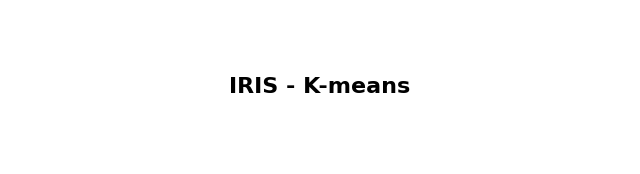

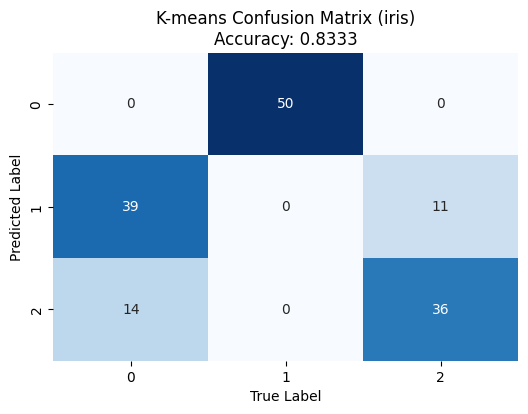

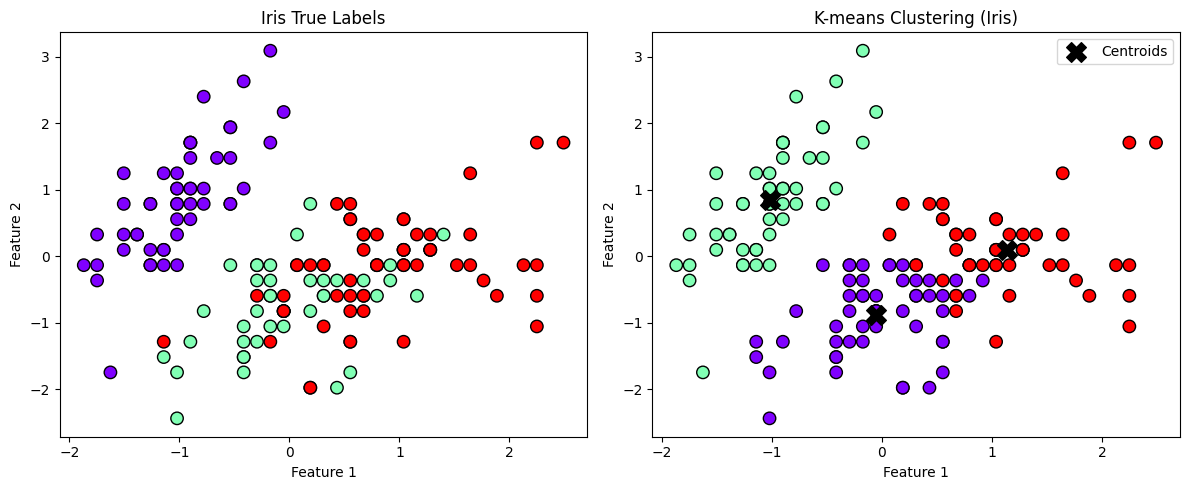

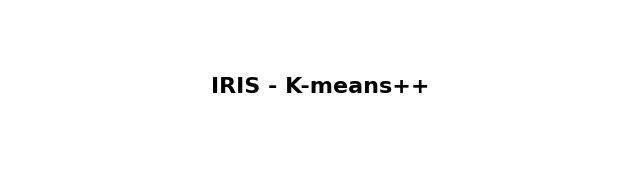

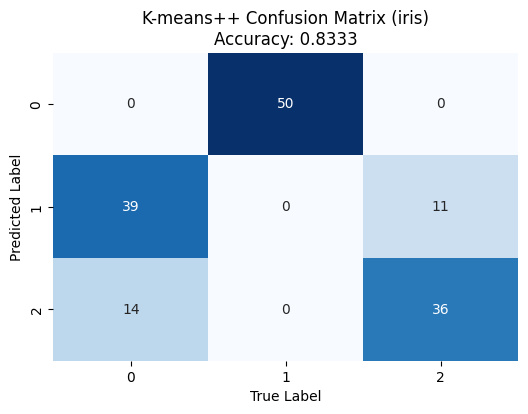

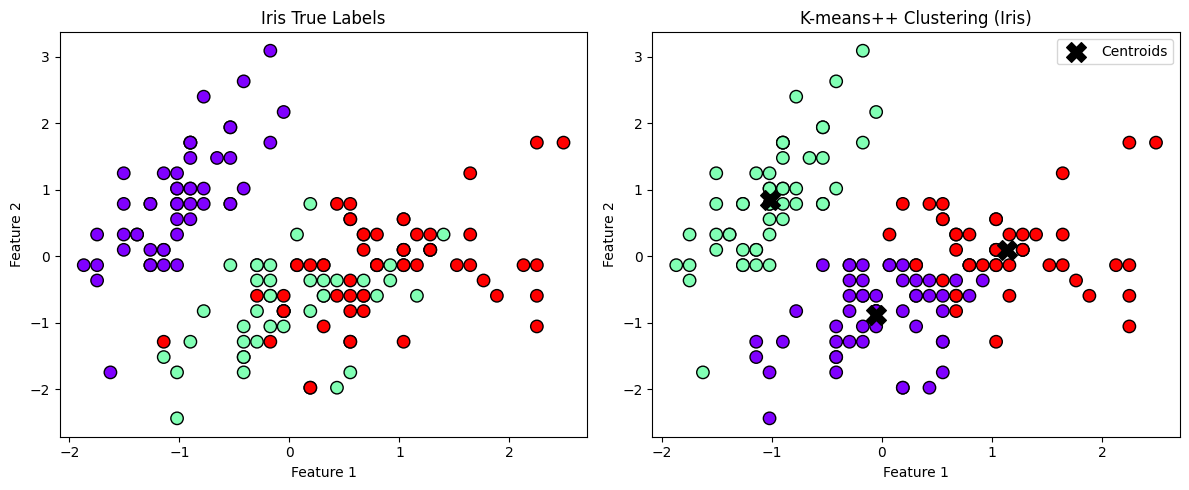

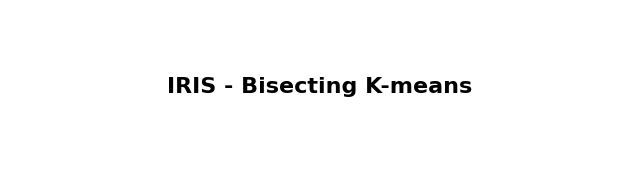

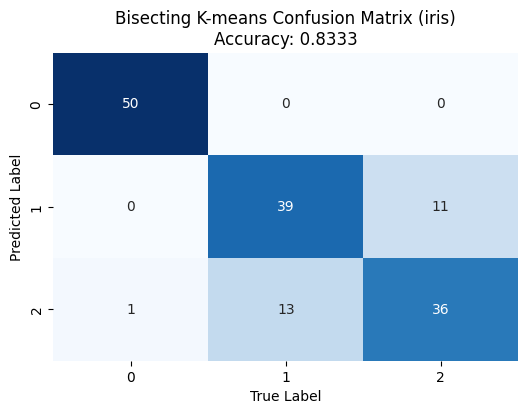

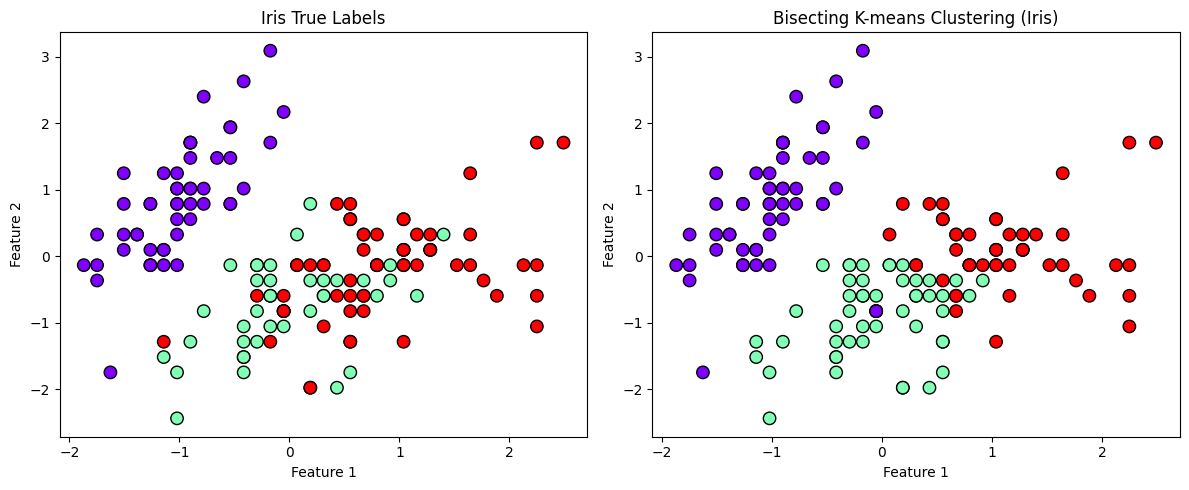

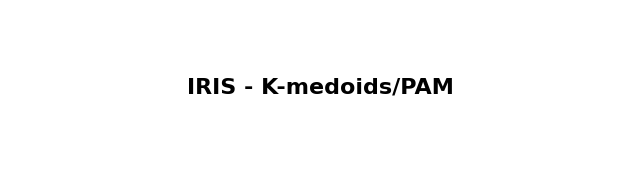

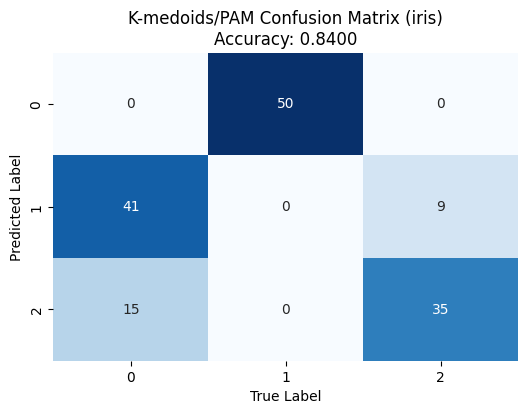

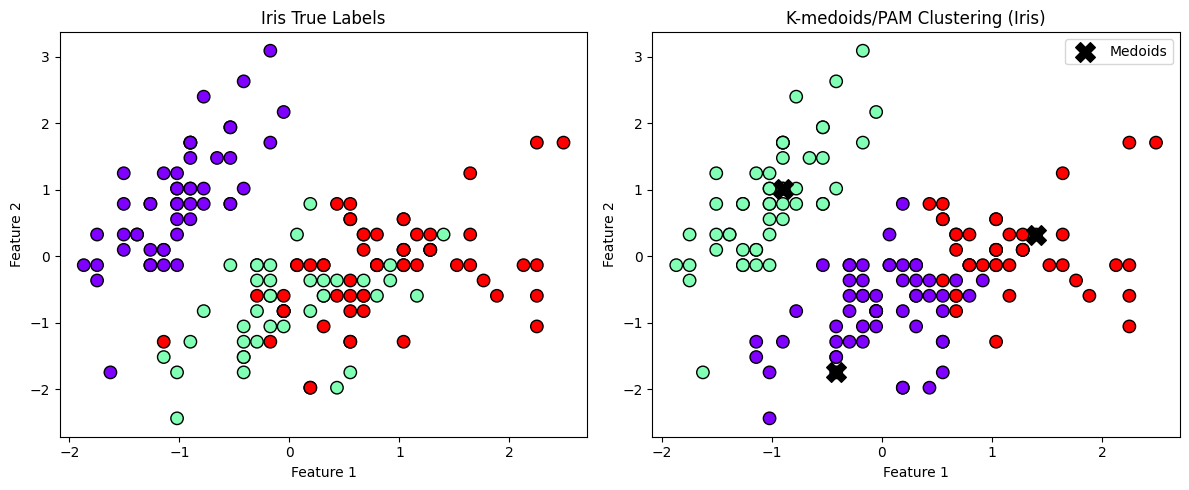

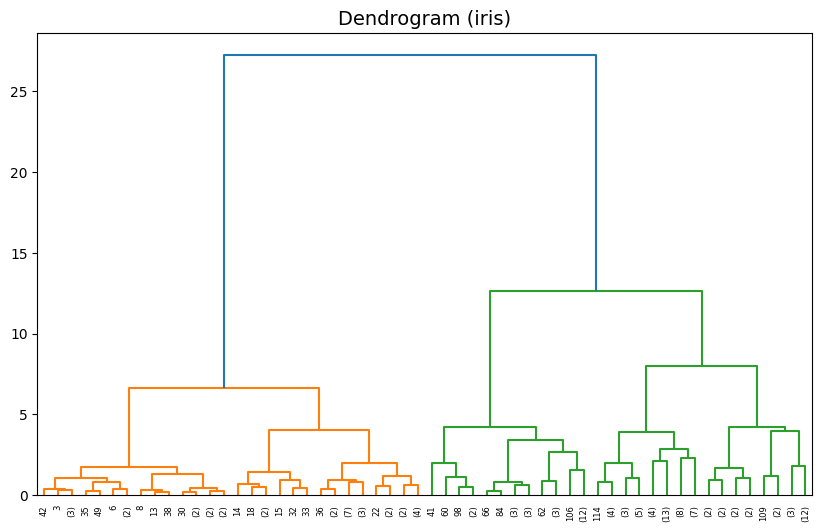

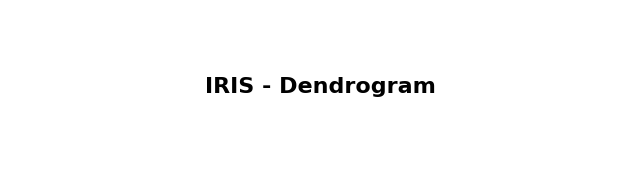

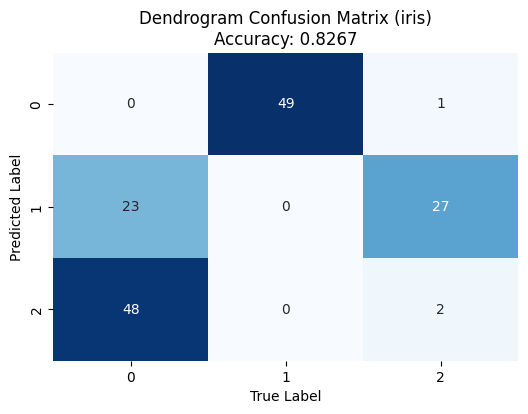

DBSCAN Cluster Labels:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1  1 -1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1  1  1  1  1  1 -1 -1  1 -1 -1  1  1  1  1 -1  1  1 -1 -1 -1
  1  1 -1  1  1 -1  1  1  1 -1 -1 -1  1  1  1 -1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1]
----------------------------------------


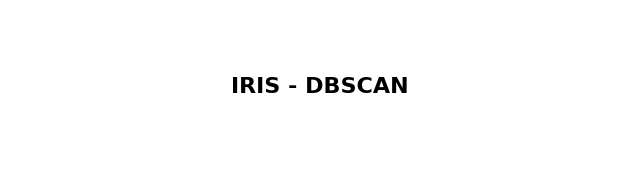

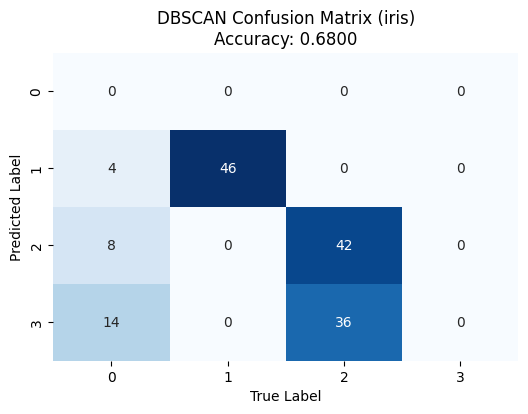

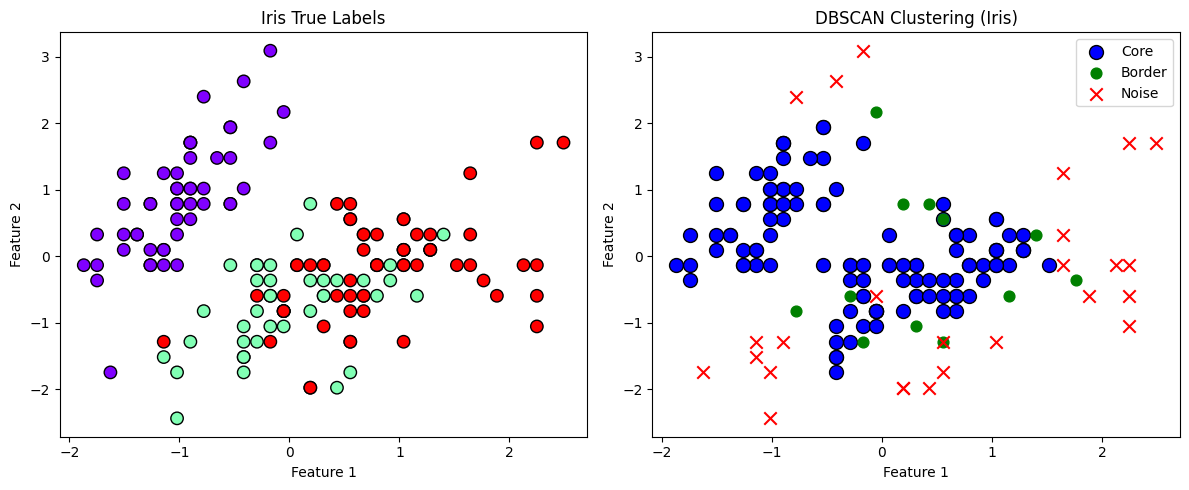

OPTICS Cluster Labels:
[ 0  1  1  1 -1 -1 -1 -1 -1  1 -1 -1  1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1
 -1  1 -1  0 -1  1  1 -1 -1 -1  1 -1 -1 -1  1  0  0 -1  1 -1 -1  1 -1  1
 -1 -1 -1 -1 -1 -1 -1  2 -1 -1 -1 -1 -1 -1 -1  3  2 -1  2 -1 -1 -1 -1  3
 -1  3  3 -1 -1 -1  3 -1 -1 -1  2 -1 -1 -1 -1 -1  2 -1  2  3 -1 -1  2  2
  2  3 -1  2 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
  4 -1 -1 -1  4 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  4  4 -1  4
  4 -1 -1 -1 -1 -1]
----------------------------------------


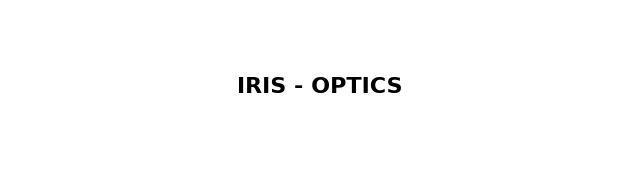

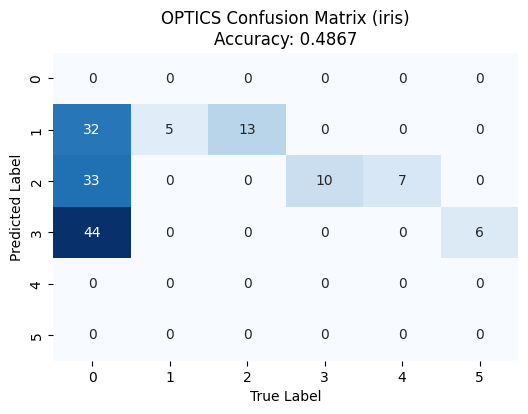

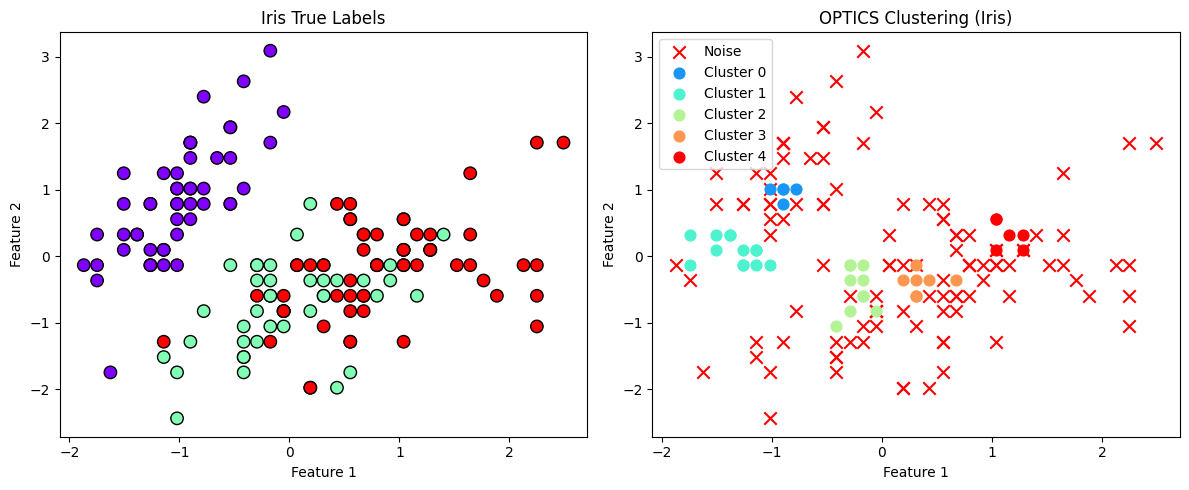

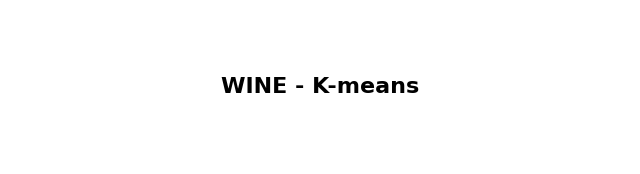

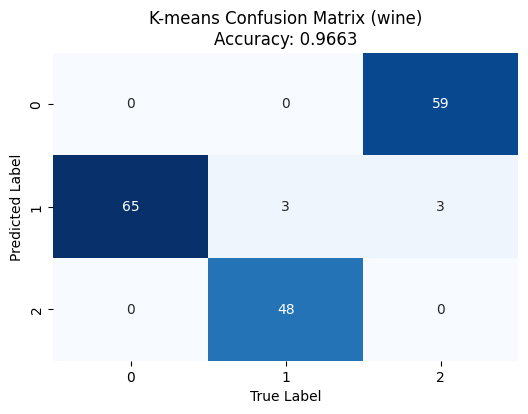

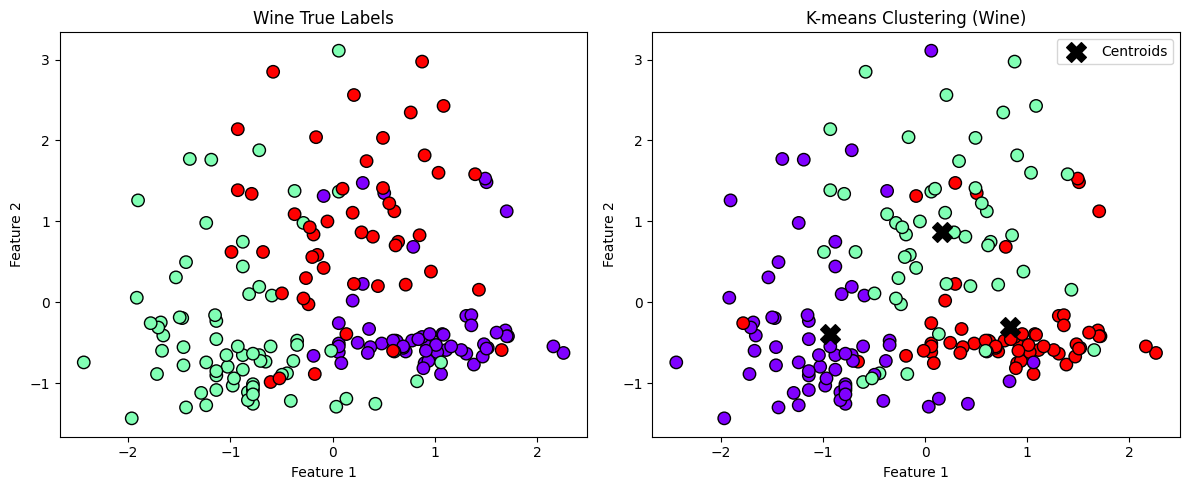

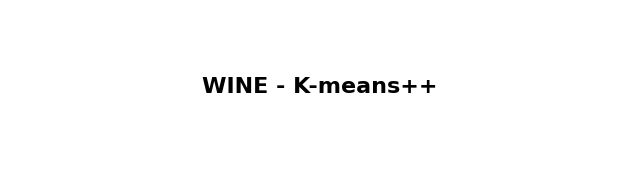

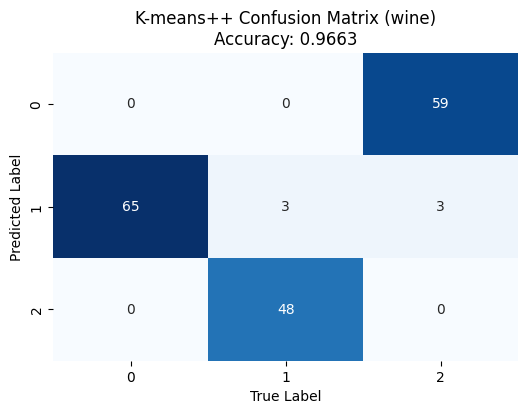

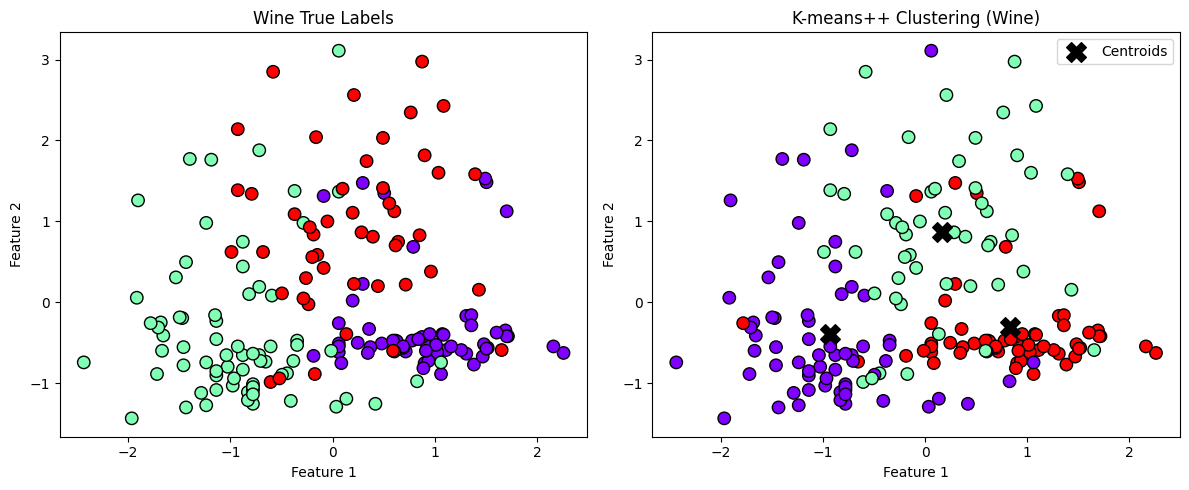

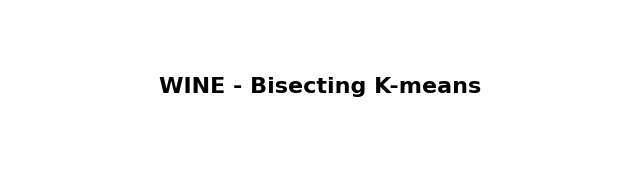

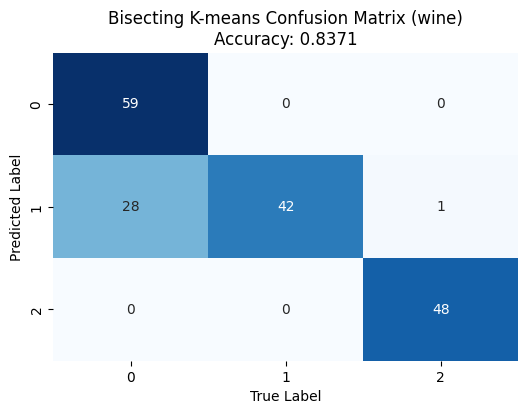

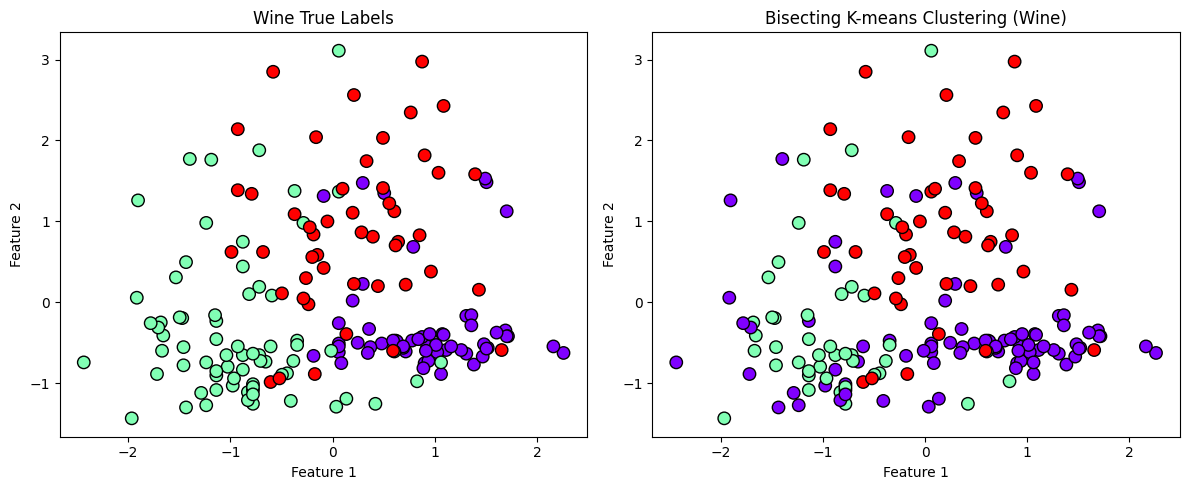

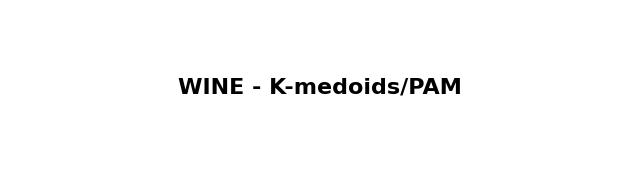

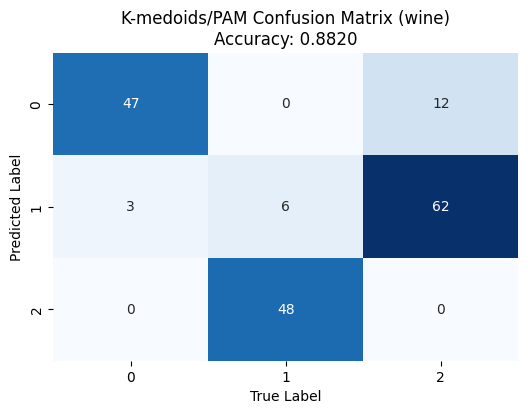

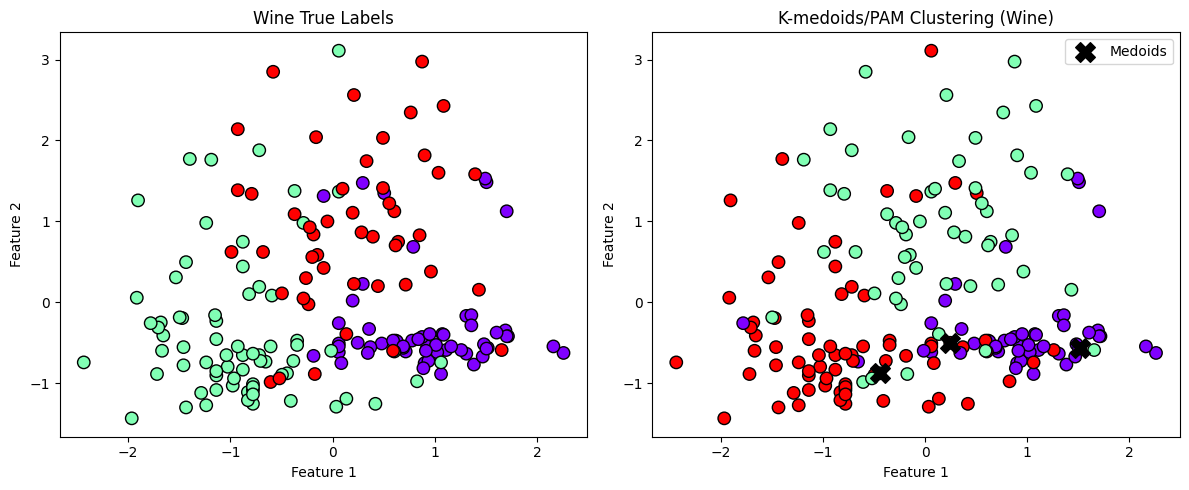

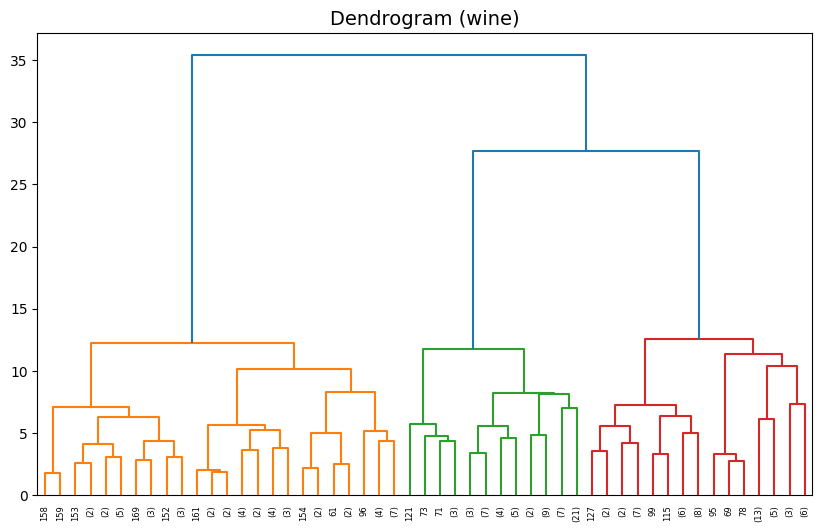

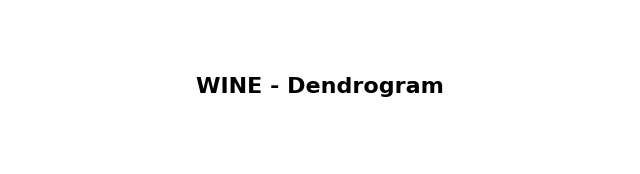

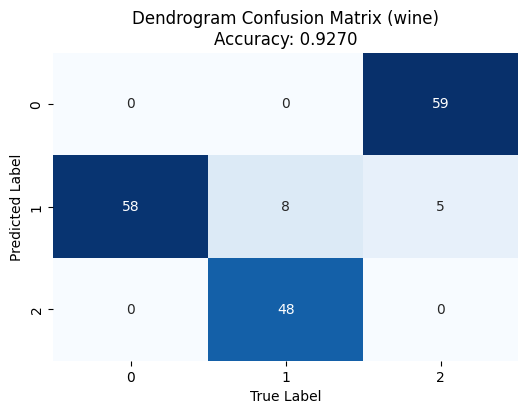

DBSCAN Cluster Labels:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0 -1  0  0
  0 -1  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1
 -1  0  0  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0
  0 -1  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0]
----------------------------------------


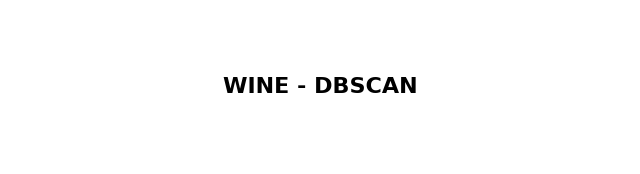

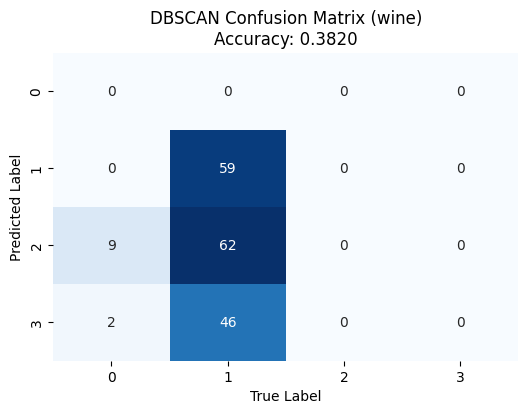

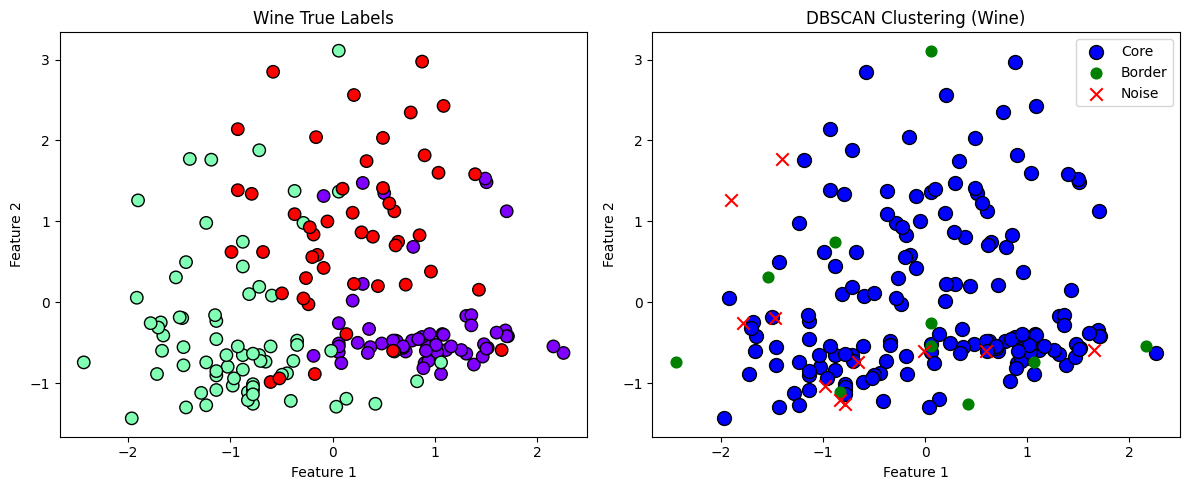

OPTICS Cluster Labels:
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1  1  1  1 -1 -1 -1
 -1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1  1 -1 -1 -1  0 -1 -1  0 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1  0  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  2  2 -1  2 -1
 -1 -1 -1  3  3 -1 -1 -1 -1 -1 -1 -1  3 -1 -1 -1  3  2  2 -1  3 -1 -1  3
 -1 -1 -1  3  3 -1  3 -1 -1 -1]
----------------------------------------


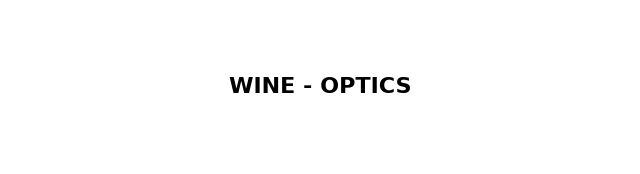

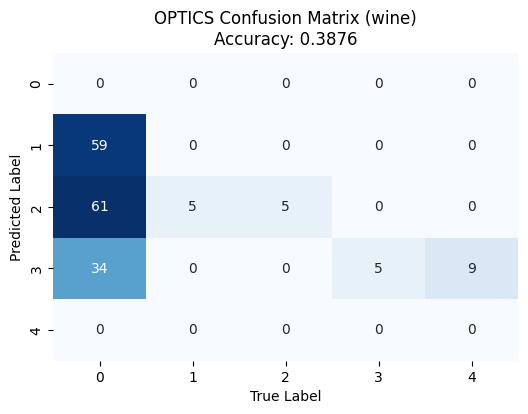

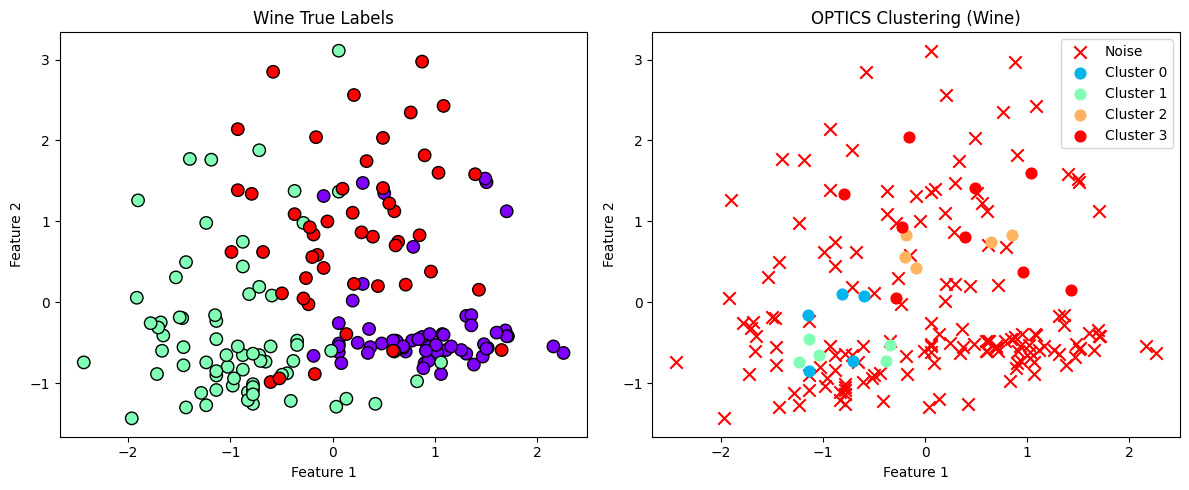

,Dataset,Model,Accuracy,Rand Score,Adjusted Rand,Mutual Info,Adjusted Mutual Info,Normalized Mutual Info,Silhouette Coefficient,Calinski-Harabasz,Davies-Bouldin,Cohesion (SSE),Separation (SSB)
0,iris,K-means,0.833333,0.832215,0.620135,0.724124,0.655223,0.659487,0.459948,241.904402,0.833595,139.820496,460.179504
1,iris,K-means++,0.833333,0.832215,0.620135,0.724124,0.655223,0.659487,0.459948,241.904402,0.833595,139.820496,460.179504
2,iris,Bisecting K-means,0.833333,0.830067,0.615220,0.700367,0.633240,0.637775,0.447692,217.162348,0.842455,151.722438,448.277562
3,iris,K-medoids/PAM,0.840000,0.836779,0.631158,0.733048,0.664557,0.668714,0.459042,239.748268,0.838455,140.782901,459.217099
4,iris,Dendrogram,0.826667,0.825235,0.615323,0.722757,0.671286,0.675470,0.446689,222.719164,0.803467,148.876256,451.123744
5,iris,DBSCAN,0.680000,0.755168,0.470627,0.569162,0.534763,0.540796,0.402762,91.023213,7.046802,268.047282,331.952718
6,iris,OPTICS,0.486667,0.512125,0.051416,0.308184,0.265690,0.292357,-0.300865,8.328211,2.425310,465.414296,134.585704
7,wine,K-means,0.966292,0.954294,0.897495,0.954458,0.874579,0.875894,0.284859,70.940008,1.389188,1277.928489,1036.071511
8,wine,K-means++,0.966292,0.954294,0.897495,0.954458,0.874579,0.875894,0.284859,70.940008,1.389188,1277.928489,1036.071511
9,wine,Bisecting K-means,0.837079,0.812988,0.590631,0.751549,0.701892,0.705090,0.234076,59.742457,1.520319,1375.112890,938.887110


In [26]:
datasets = ['iris','wine']
models = ['K-means','K-means++','Bisecting K-means','K-medoids/PAM','Dendrogram','DBSCAN','OPTICS']

all_results = []
for ds in datasets:
    for mdl in models:
        metrics = evaluate_clustering(mdl, ds)
        if metrics is not None:
            metrics['Model'] = mdl
            metrics['Dataset'] = ds
            all_results.append(metrics)

# ------------------- SUMMARY TABLE -------------------
results_df = pd.DataFrame(all_results)
results_df = results_df[['Dataset','Model','Accuracy','Rand Score','Adjusted Rand','Mutual Info',
                         'Adjusted Mutual Info','Normalized Mutual Info','Silhouette Coefficient',
                         'Calinski-Harabasz','Davies-Bouldin','Cohesion (SSE)','Separation (SSB)']]
display(results_df.style.background_gradient(cmap='YlGnBu'))


#Discussion

**IRIS Dataset**

1. K-means Accuracy 0.833: Correctly classifies ~83% of iris samples.

2. K-means Rand Score 0.832: High agreement between predicted and true labels.

3. K-means Adjusted Rand 0.620: Good clustering, adjusted for chance.

4. K-means Mutual Info 0.724: Cluster assignments share substantial information with true labels.

5. K-means Adjusted Mutual Info 0.655: After chance correction, mutual info remains strong.

6. K-means Normalized Mutual Info 0.659: Consistent information normalized, moderate-high.

7. K-means Silhouette 0.459: Moderate cluster separation and cohesion.

8. K-means Calinski-Harabasz 241.90: Good separation among clusters.

9. K-means Davies-Bouldin 0.833: Low value indicates better cluster compactness.

10. K-means Cohesion (SSE) 139.82: Moderate within-cluster variance.

11. K-means Separation (SSB) 460.17: Between-cluster separation is strong.

12. K-means++ metrics identical to K-means: Initialization method didn’t change results much.

13. Bisecting K-means Accuracy 0.833: Similar performance to K-means, slightly lower adjusted rand.

14. Bisecting K-means Silhouette 0.448: Slightly lower cluster separation than standard K-means.

15. K-medoids/PAM Accuracy 0.84: Slightly better classification than K-means.

16. K-medoids Silhouette 0.459: Cluster shapes preserved well using medoids.

17. Dendrogram Accuracy 0.826: Hierarchical clustering slightly lower than K-medoids/K-means.

18. Dendrogram Silhouette 0.446: Clusters moderately separated.

19. DBSCAN Accuracy 0.68: Lower performance due to sensitivity to eps/min_samples.

20. DBSCAN Silhouette 0.403: Clusters less compact; noise points present.

21. OPTICS Accuracy 0.486: Poor clustering; noise points dominate.

22. OPTICS Silhouette -0.30: Negative value indicates wrong or overlapping cluster structure.

---

**WINE Dataset**

1. K-means Accuracy 0.966: Excellent clustering for wine features.

2. K-means Rand Score 0.954: High alignment with true labels.

3. K-means Adjusted Rand 0.897: Very strong clustering quality.

4. K-means Mutual Info 0.954: Clusters capture almost all true label info.

5. K-means Adjusted Mutual Info 0.874: Slight reduction after chance correction.

6. K-means Normalized Mutual Info 0.875: High normalized information.

7. K-means Silhouette 0.284: Moderate separation; more overlap due to high-dimensional data.

8. K-means Calinski-Harabasz 70.94: Moderate separation among clusters.

9. K-means Davies-Bouldin 1.389: Low cluster compactness, reasonable clustering.

10. K-means Cohesion 1277.93: Larger SSE due to higher feature dimensions.

11. K-means Separation 1036.07: Strong between-cluster separation.

12. K-means++ same as K-means: Initialization doesn’t significantly affect results.

13. Bisecting K-means Accuracy 0.837: Lower than standard K-means for wine.

14. K-medoids/PAM Accuracy 0.882: Better than bisecting K-means, slightly below K-means.

15. Dendrogram Accuracy 0.926: Hierarchical clustering performs well for wine.

16. DBSCAN Accuracy 0.382: Poor clustering; high-dimensionality affects density-based clustering.

17. OPTICS Accuracy 0.387: Also poor; noise dominates, unsuitable for wine dataset.

---

**Comparison Overview (Iris vs Wine)**

1. K-means performs very well for both datasets, slightly better on wine.
2. K-means++ gives almost identical results to K-means for both datasets.
3. Bisecting K-means is slightly worse than K-means for both datasets.
4. K-medoids is competitive on iris and moderately good on wine.
5. Dendrogram performs reasonably on both, slightly better on wine.
6. DBSCAN and OPTICS struggle on wine due to high-dimensional data, perform better on iris.
7. Silhouette scores are higher for iris; clusters are more compact in lower dimensions.
8. Cohesion (SSE) is higher for wine due to more features; separation is also higher.
9. Density-based methods (DBSCAN, OPTICS) are sensitive to dataset properties.
10. Overall, K-means and hierarchical methods are most robust across datasets.

---

**Final Conclusion**

1. For low-dimensional datasets like Iris, most clustering methods perform reasonably, with K-means/K-medoids best.
2. For high-dimensional datasets like Wine, K-means excels, DBSCAN/OPTICS fail due to sparsity.
3. Hierarchical clustering is stable for both but slightly less accurate than K-means on Wine.
4. Density-based methods are dataset-sensitive and better for low-dimensional, well-separated clusters.
5. K-means remains the most reliable general-purpose clustering method across both datasets.

